# U-Net Oil Spill Semantic Segmentation Pipeline Demo

Semantic segmentation pipeline using a trained U-Net model on a single validation image. We apply different noise filters and visualize the model's output probability map and final binarized predictions.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import torch

sys.path.append('../src')
import noise_filter
from unet import UNet

## 1. Load Data

We select a validation image (`palsar_0.png`) and its corresponding ground truth mask for visualization.

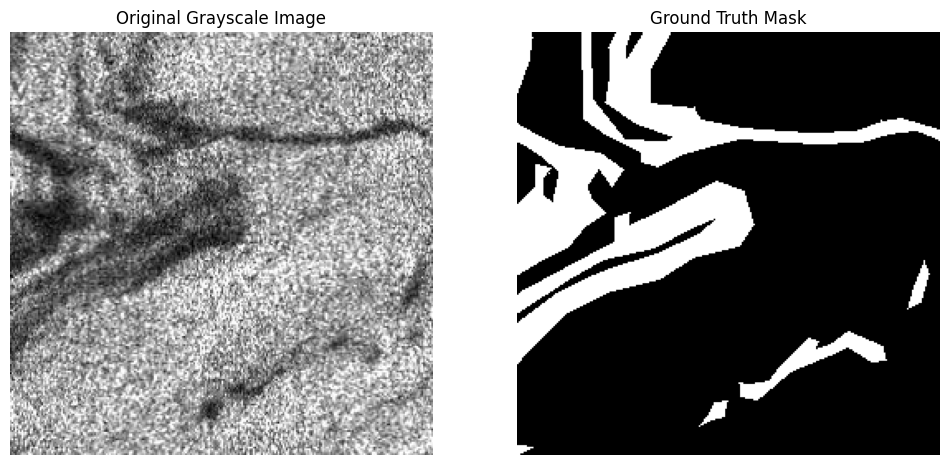

In [2]:
img_path = Path("../data/images/images/val/palsar_0.png")
mask_path = Path("../data/masks/masks/val/palsar_0.png")

img = noise_filter.load_image(img_path)
mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")
plt.show()

## 2. Define Inference Function

Function that loads the trained U-Net checkpoint, resizes and normalizes the input image, passes it through the network, and outputs both the probability map and the binarized segmentation mask.

In [3]:
def predict_unet(img_filtered, model_path, device="cuda" if torch.cuda.is_available() else "cpu"):
    model = UNet(n_channels=1, n_classes=1, bilinear=True)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    # Resize to 256x256
    img_resized = cv2.resize(img_filtered, (256, 256), interpolation=cv2.INTER_LINEAR)
    img_norm = img_resized.astype(np.float32) / 255.0
    img_tensor = torch.tensor(img_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(img_tensor)
        # Output logits from unet should be mapped to [0, 1] using Sigmoid
        preds = torch.sigmoid(logits)
        pred_prob = preds.squeeze().cpu().numpy()
        
    pred_bin = (pred_prob > 0.5).astype(np.uint8) * 255
    return pred_prob, pred_bin

## 3. Run Pipeline for Every Filter

We iterate over all filters applied in the first part, process the image, perform inference with the corresponding U-Net model, and collect the results.

In [4]:
filters = ["none", "median", "gaussian", "bilateral", "blur"]
predictions = {}

for f in filters:
    # Apply filter
    filtered_img = noise_filter.filter_img(img, f)
    
    # Run prediction
    model_file = f"../models/unet_{f}.pth"
    if Path(model_file).exists():
        prob, binarized = predict_unet(filtered_img, model_file)
        predictions[f] = (filtered_img, prob, binarized)
        print(f"Prediction successful for U-Net with filter: {f}")
    else:
        print(f"Model file {model_file} not found. Please train all filters first.")

Prediction successful for U-Net with filter: none
Prediction successful for U-Net with filter: median
Model file ../models/unet_gaussian.pth not found. Please train all filters first.
Model file ../models/unet_bilateral.pth not found. Please train all filters first.
Model file ../models/unet_blur.pth not found. Please train all filters first.


## 4. Visual Comparison of Segmentation Predictions

We plot the filtered input image, the raw output probability map from the U-Net, and the binarized segmentation mask side-by-side for each filter.

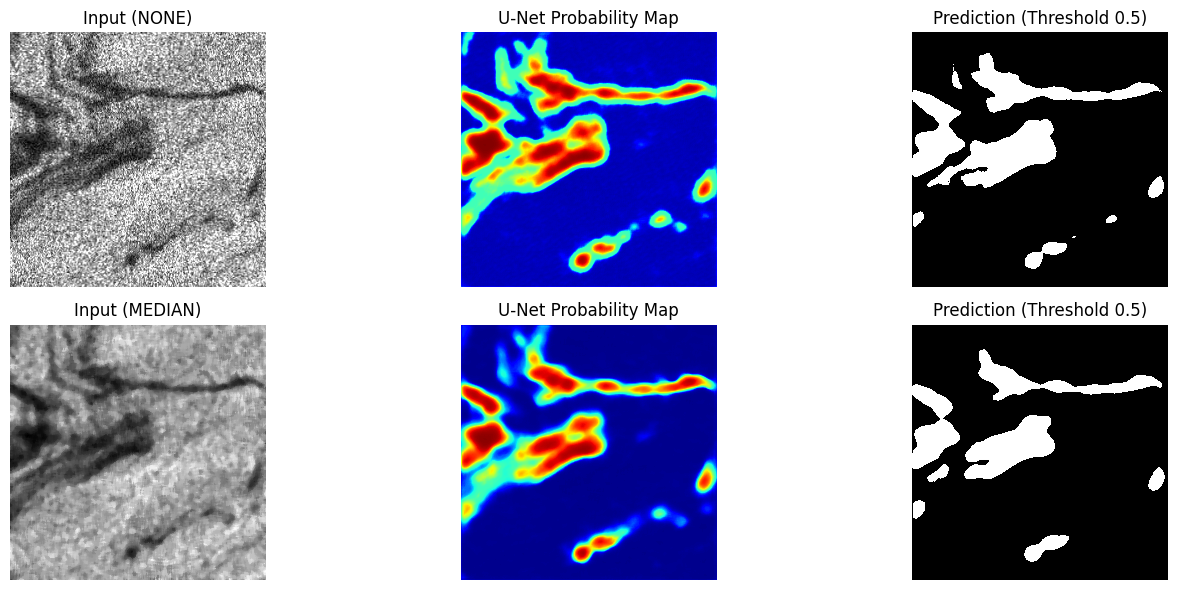

In [5]:
if len(predictions) > 0:
    fig, axes = plt.subplots(len(predictions), 3, figsize=(15, 3 * len(predictions)))
    for i, (f, (filtered_img, prob, binarized)) in enumerate(predictions.items()):
        # Filtered input
        axes[i, 0].imshow(filtered_img, cmap="gray")
        axes[i, 0].set_title(f"Input ({f.upper()})")
        axes[i, 0].axis("off")
        
        # U-Net probability map
        im = axes[i, 1].imshow(prob, cmap="jet", vmin=0, vmax=1)
        axes[i, 1].set_title(f"U-Net Probability Map")
        axes[i, 1].axis("off")
        
        # Binarized prediction
        axes[i, 2].imshow(binarized, cmap="gray")
        axes[i, 2].set_title(f"Prediction (Threshold 0.5)")
        axes[i, 2].axis("off")
        
    plt.tight_layout()
    plt.show()
else:
    print("No prediction results to display. Please train models first.")